# CS 181 Homework 5

This notebook keeps the original assignment scaffold and is organized around the four homework problems:

- **Problem 1: SimCLR**
- **Problem 2: GANs**
- **Problem 3: Clustering**
- **Problem 4: PCA**

## How to read this notebook

1. Start each problem by reading the overview-and-roadmap markdown cell.
2. Then read the code cells in order; they follow the intended implementation flow from the assignment.
3. Generated clustering and PCA figures are saved in `img_output/`.
4. Some training cells are intentionally expensive; read the notes before running them end to end.


## Problem 1: SimCLR


### Overview and Roadmap

This section is meant to be read in the same order a student would work the problem. The notebook structure mirrors the assignment scaffold rather than jumping straight to the final training loop.

#### What this problem asks you to do

1. Understand the encoder architecture that produces feature vectors.
2. Implement the projection head used only during contrastive training.
3. Implement the NT-Xent objective carefully and verify it on a hand-worked example.
4. Use the provided augmentation pipeline to pre-train without labels.
5. Freeze the encoder, train a linear classifier on top, and compare against supervised training.

#### How the code below is organized

- The early code cells define reusable building blocks.
- The middle cells check correctness before expensive training runs.
- The later cells run the full SimCLR pipeline and summarize the comparison.


The imports are grouped to support the full SimCLR pipeline: PyTorch for the model and optimization, `torchvision` for FashionMNIST and augmentations, and `matplotlib` for quick visual checks.


### Setup and Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Section 1.1: Backbone Encoder


In [2]:
BASE_CHANNELS = 32
NUM_BLOCKS = 3


class ResBlock(nn.Module):
    """Basic residual block: two 3x3 convs with BN and a skip connection."""

    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)


class SimCLREncoder(nn.Module):
    """ResNet encoder for SimCLR (no classification head)."""

    def __init__(self, num_blocks=NUM_BLOCKS, base_channels=BASE_CHANNELS):
        super().__init__()
        C = base_channels
        self.out_dim = C

        self.stem = nn.Sequential(
            nn.Conv2d(1, C, 3, padding=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.blocks = nn.Sequential(*[ResBlock(C) for _ in range(num_blocks)])
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.pool(x)
        return torch.flatten(x, 1)  # (B, C)


enc_test = SimCLREncoder()
dummy = torch.randn(2, 1, 28, 28)
print(f"Encoder output shape: {enc_test(dummy).shape}")  # (2, 32)
print(f"Encoder parameters: {sum(p.numel() for p in enc_test.parameters()):,}")

Encoder output shape: torch.Size([2, 32])
Encoder parameters: 56,032


### Section 1.2: Implementing SimCLR Components


#### Subpart 1.2.a: Projection Head


In [3]:
class ProjectionHead(nn.Module):
    """Two-layer MLP projection head for SimCLR."""

    def __init__(self, input_dim, hidden_dim=128, output_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, h):
        return self.mlp(h)


#### Subpart 1.2.b: NT-Xent Loss


In [4]:
def nt_xent_loss(z1, z2, temperature=0.5):
    """
    NT-Xent (Normalized Temperature-scaled Cross-Entropy) loss.

    Args:
        z1: (N, D) projected representations of first augmented views
        z2: (N, D) projected representations of second augmented views
        temperature: temperature scaling parameter tau

    Returns:
        Scalar loss (mean over all 2N positive pairs)
    """
    N = z1.shape[0]

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    z = torch.cat([z1, z2], dim=0)  # (2N, D)

    sim = torch.mm(z, z.t()) / temperature  # (2N, 2N)

    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float('-inf'))

    labels = torch.cat([torch.arange(N, 2 * N), torch.arange(0, N)]).to(z.device)

    loss = F.cross_entropy(sim, labels)

    return loss

#### Check 1.2.c: Hand Calculation


In [5]:
z1_test = torch.tensor([[1.0, 0.0], [0.0, 2.0]])   # views 1,2 (images A, B)
z2_test = torch.tensor([[3.0, 4.0], [-4.0, 3.0]])   # views 3,4 (images A, B)

loss_hand = nt_xent_loss(z1_test, z2_test, temperature=1.0)
print(f"NT-Xent loss (tau=1.0): {loss_hand.item():.4f}")
assert abs(loss_hand.item() - 0.802) < 0.01, f"Loss mismatch: {loss_hand.item()}"

NT-Xent loss (tau=1.0): 0.8021


#### Check 1.2.d: Public Test Cases


In [6]:
def test_nt_xent_hand_calculation():
    """Public test: matches the hand-calculation check above."""
    z1 = torch.tensor([[1.0, 0.0], [0.0, 2.0]])
    z2 = torch.tensor([[3.0, 4.0], [-4.0, 3.0]])
    loss = nt_xent_loss(z1, z2, temperature=1.0)
    assert abs(loss.item() - 0.802) < 0.01
    print("  [PASS] test_nt_xent_hand_calculation")


def test_nt_xent_temperature_effect():
    """Lower temperature should give higher loss (sharper distribution)."""
    z1 = torch.randn(16, 8)
    z2 = torch.randn(16, 8)
    loss_low_t = nt_xent_loss(z1, z2, temperature=0.1)
    loss_high_t = nt_xent_loss(z1, z2, temperature=2.0)
    assert loss_low_t.item() > loss_high_t.item()
    print("  [PASS] test_nt_xent_temperature_effect")


# Run the public tests
test_nt_xent_hand_calculation()
test_nt_xent_temperature_effect()
print("\nPublic tests passed!")


  [PASS] test_nt_xent_hand_calculation
  [PASS] test_nt_xent_temperature_effect

Public tests passed!


### Section 1.3: SimCLR Training and Linear Evaluation


#### Subpart 1.3.a: Data Loading and Augmentations


In [7]:
class SimCLRAugmentation:
    """Returns two different augmented views of the same image."""

    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(28, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomApply(
                [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))],
                p=0.5,
            ),
            transforms.ToTensor(),
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)


simclr_aug = SimCLRAugmentation()

train_ds_simclr = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=simclr_aug,
)
train_ds_supervised = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor(),
)
test_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transforms.ToTensor(),
)

print(f"Training set size: {len(train_ds_simclr)}")
print(f"Test set size: {len(test_ds)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.85MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
 12%|█▏        | 524k/4.42M [00:00<00:04, 867kB/s] 100%|██████████| 4.42M/4.42M [00:01<00:00, 3.34MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.8MB/s]

Training set size: 60000
Test set size: 10000


##### Visual Check: Augmentations


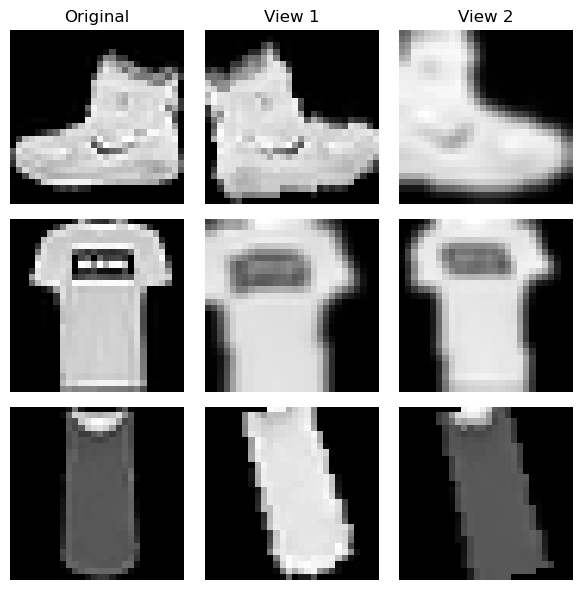

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for row in range(3):
    img, _ = train_ds_supervised[row]
    axes[row, 0].imshow(img.squeeze(), cmap="gray")
    axes[row, 0].set_title("Original" if row == 0 else "")

    (v1, v2), _ = train_ds_simclr[row]
    axes[row, 1].imshow(v1.squeeze(), cmap="gray")
    axes[row, 1].set_title("View 1" if row == 0 else "")
    axes[row, 2].imshow(v2.squeeze(), cmap="gray")
    axes[row, 2].set_title("View 2" if row == 0 else "")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

#### Subpart 1.3.b: SimCLR Pre-training


In [10]:
# Hyperparameters
SIMCLR_EPOCHS = 10
SIMCLR_BATCH_SIZE = 512
SIMCLR_LR = 1e-3
SIMCLR_TEMPERATURE = 0.5
PROJECTION_HIDDEN = 128
PROJECTION_DIM = 64

RUN_SIMCLR_TRAINING = True  # Set to False if you want to skip the expensive training run while developing earlier parts

In [11]:
def train_simclr(encoder, proj_head, train_loader, epochs, lr, temperature, device):
    """
    Train SimCLR: encoder + projection head with NT-Xent loss.

    Args:
        encoder: SimCLREncoder instance
        proj_head: ProjectionHead instance
        train_loader: DataLoader yielding ((view1, view2), labels)
        epochs: number of training epochs
        lr: learning rate
        temperature: NT-Xent temperature
        device: torch device

    Returns:
        List of average loss per epoch
    """
    params = list(encoder.parameters()) + list(proj_head.parameters())
    optimizer = optim.Adam(params, lr=lr)
    loss_history = []

    encoder.train()
    proj_head.train()

    for epoch in range(epochs):
        total_loss = 0.0
        num_batches = 0

        for (x1, x2), _ in train_loader:
            x1, x2 = x1.to(device), x2.to(device)

            h1 = encoder(x1)
            h2 = encoder(x2)

            z1 = proj_head(h1)
            z2 = proj_head(h2)

            loss = nt_xent_loss(z1, z2, temperature)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
        print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}")

    return loss_history

SimCLR pre-training, it may takes ~20 minutes on CPU:


/opt/homebrew/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Epoch  1/10  loss=5.4151
  Epoch  2/10  loss=5.1884
  Epoch  3/10  loss=5.1552
  Epoch  4/10  loss=5.1401
  Epoch  5/10  loss=5.1285
  Epoch  6/10  loss=5.1217
  Epoch  7/10  loss=5.1147
  Epoch  8/10  loss=5.1084
  Epoch  9/10  loss=5.1049
  Epoch 10/10  loss=5.1008


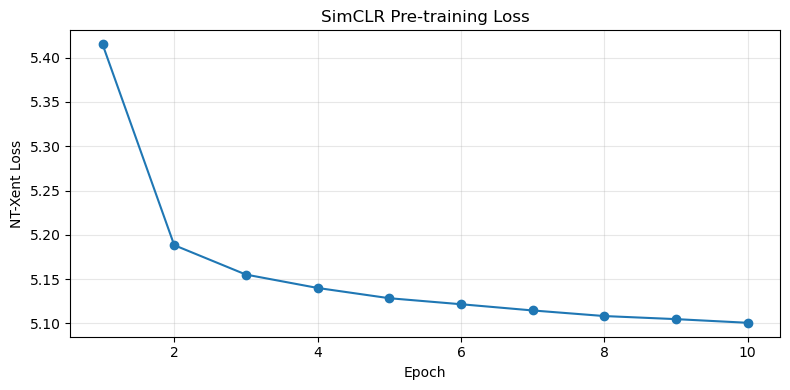

In [12]:
if RUN_SIMCLR_TRAINING:
    torch.manual_seed(SEED)

    simclr_encoder = SimCLREncoder(NUM_BLOCKS, BASE_CHANNELS).to(device)
    simclr_proj = ProjectionHead(
        input_dim=BASE_CHANNELS,
        hidden_dim=PROJECTION_HIDDEN,
        output_dim=PROJECTION_DIM,
    ).to(device)

    simclr_loader = DataLoader(
        train_ds_simclr, batch_size=SIMCLR_BATCH_SIZE, shuffle=True,
        num_workers=0, pin_memory=True, drop_last=True,
    )

    print("SimCLR pre-training, it may takes ~20 minutes on CPU:")
    simclr_losses = train_simclr(
        simclr_encoder, simclr_proj, simclr_loader,
        epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
        temperature=SIMCLR_TEMPERATURE, device=device,
    )

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(simclr_losses) + 1), simclr_losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("NT-Xent Loss")
    plt.title("SimCLR Pre-training Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Subpart 1.3.c: Linear Evaluation


In [13]:
@torch.no_grad()
def extract_representations(encoder, dataset, device, batch_size=512):
    """Extract encoder representations for an entire dataset."""
    encoder.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    all_h, all_y = [], []
    for x, y in loader:
        h = encoder(x.to(device))
        all_h.append(h.cpu())
        all_y.append(y)
    return torch.cat(all_h), torch.cat(all_y)


def linear_eval(encoder, train_dataset, test_dataset, device,
                epochs=20, lr=1e-2, batch_size=256):
    """
    Linear evaluation protocol: train a linear classifier on frozen representations.

    Args:
        encoder: pre-trained encoder (will be frozen)
        train_dataset: training dataset (with ToTensor transform)
        test_dataset: test dataset
        device: torch device
        epochs: number of training epochs for the linear classifier
        lr: learning rate
        batch_size: batch size

    Returns:
        test_accuracy: float
    """
    print("  Extracting representations...")
    h_train, y_train = extract_representations(encoder, train_dataset, device)
    h_test, y_test = extract_representations(encoder, test_dataset, device)

    train_loader = DataLoader(
        TensorDataset(h_train, y_train),
        batch_size=batch_size, shuffle=True,
    )

    classifier = nn.Linear(encoder.out_dim, 10).to(device)
    optimizer = optim.Adam(classifier.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    classifier.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for h_batch, y_batch in train_loader:
            h_batch, y_batch = h_batch.to(device), y_batch.to(device)
            logits = classifier(h_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"    Epoch {epoch+1:2d}/{epochs}  loss={total_loss / len(train_loader):.4f}")

    classifier.eval()
    h_test_dev = h_test.to(device)
    y_test_dev = y_test.to(device)
    with torch.no_grad():
        preds = classifier(h_test_dev).argmax(dim=1)
        accuracy = (preds == y_test_dev).float().mean().item()

    return accuracy

In [14]:
if RUN_SIMCLR_TRAINING:
    print("Linear evaluation of SimCLR encoder:")
    simclr_accuracy = linear_eval(
        simclr_encoder, train_ds_supervised, test_ds, device,
        epochs=20, lr=1e-2,
    )
    print(f"\nSimCLR linear eval test accuracy: {simclr_accuracy:.4f}")

Linear evaluation of SimCLR encoder:
  Extracting representations...
    Epoch  5/20  loss=0.7778
    Epoch 10/20  loss=0.7462
    Epoch 15/20  loss=0.7327
    Epoch 20/20  loss=0.7259

SimCLR linear eval test accuracy: 0.7352


#### Subpart 1.3.d: Supervised Baseline


In [17]:
class SupervisedModel(nn.Module):
    """Encoder + linear classifier, trained end-to-end."""

    def __init__(self, num_blocks=NUM_BLOCKS, base_channels=BASE_CHANNELS, num_classes=10):
        super().__init__()
        self.encoder = SimCLREncoder(num_blocks, base_channels)
        self.fc = nn.Linear(base_channels, num_classes)

    def forward(self, x):
        h = self.encoder(x)
        return self.fc(h)


def train_supervised(model, train_dataset, test_dataset, device,
                     epochs=10, lr=1e-3, batch_size=512):
    """Standard supervised training loop."""
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=512, shuffle=False, num_workers=0,
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for x, y in test_loader:
                    x, y = x.to(device), y.to(device)
                    preds = model(x).argmax(dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)
            print(f"  Epoch {epoch+1:2d}/{epochs}  loss={total_loss/len(train_loader):.4f}  "
                  f"test_acc={correct/total:.4f}")

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [16]:
if RUN_SIMCLR_TRAINING:
    torch.manual_seed(SEED)
    sup_model = SupervisedModel().to(device)
    print("Supervised baseline training, it may takes ~20 minutes on CPU:")
    sup_accuracy = train_supervised(
        sup_model, train_ds_supervised, test_ds, device,
        epochs=10, lr=1e-3,
    )
    print(f"\nSupervised test accuracy: {sup_accuracy:.4f}")

Supervised baseline training, it may takes ~20 minutes on CPU:
  Epoch  5/10  loss=0.3011  test_acc=0.8208
  Epoch 10/10  loss=0.2325  test_acc=0.8334

Supervised test accuracy: 0.8334


#### Subpart 1.3.e: Comparison


Results Summary
SimCLR (linear eval):     0.7352
Supervised (end-to-end):  0.8334
Gap:                      0.0982

SimCLR learns useful representations without any labels.
The gap to supervised training is expected — SimCLR uses only
a linear classifier on frozen features, while supervised
training jointly optimizes the encoder and classifier.


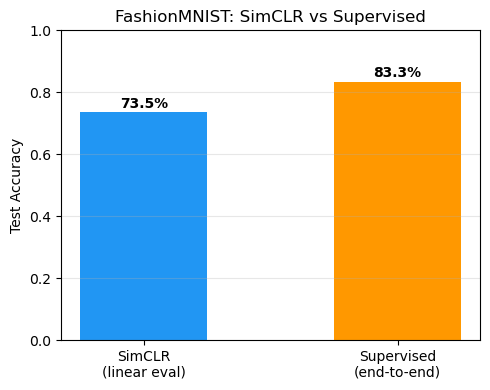

In [20]:
if RUN_SIMCLR_TRAINING:
    print("=" * 50)
    print("Results Summary")
    print("=" * 50)
    print(f"SimCLR (linear eval):     {simclr_accuracy:.4f}")
    print(f"Supervised (end-to-end):  {sup_accuracy:.4f}")
    print(f"Gap:                      {sup_accuracy - simclr_accuracy:.4f}")
    print()
    print("SimCLR learns useful representations without any labels.")
    print("The gap to supervised training is expected — SimCLR uses only")
    print("a linear classifier on frozen features, while supervised")
    print("training jointly optimizes the encoder and classifier.")

    methods = ["SimCLR\n(linear eval)", "Supervised\n(end-to-end)"]
    accs = [simclr_accuracy, sup_accuracy]

    plt.figure(figsize=(5, 4))
    bars = plt.bar(methods, accs, color=["#2196F3", "#FF9800"], width=0.5)
    for bar, acc in zip(bars, accs):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{acc:.1%}", ha="center", va="bottom", fontweight="bold")
    plt.ylabel("Test Accuracy")
    plt.title("FashionMNIST: SimCLR vs Supervised")
    plt.ylim(0, 1.0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Problem 2: GANs


### Overview and Roadmap

This part is shorter than the SimCLR section, but it still follows a clear implementation scaffold rather than a single monolithic training block.

#### What this problem asks you to do

1. Set up the MNIST training data and latent-noise dimension.
2. Define a generator and discriminator.
3. Implement the discriminator loss on real and fake batches.
4. Implement the generator loss that encourages fake samples to look real.
5. Alternate the two updates inside a training loop and visualize generated digits.

#### Reading guide

- The model-definition cells tell you what objects are being optimized.
- The loss cells isolate the two optimization objectives.
- The `train_one_epoch` cell is the key place where the alternating-update logic is implemented.


### Section 2.1: Practical GAN Implementation


#### Subpart 2.1.a: Setup and Data Loading

These cells choose a device, load MNIST, normalize images to the `[-1, 1]` range expected by the generator output, and build the dataloader used during training.


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [23]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 524kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.84MB/s]


#### Subpart 2.1.b: Generator and Discriminator

The generator maps latent noise vectors to flattened images, while the discriminator maps flattened images to real/fake probabilities. Keep the input and output shapes in mind while reading the implementation.


In [24]:
latent_dim = 100
image_dim = 28 * 28

G = nn.Sequential(
    nn.Linear(latent_dim, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 512),
    nn.LeakyReLU(0.2),
    nn.Linear(512, 1024),
    nn.LeakyReLU(0.2),
    nn.Linear(1024, image_dim),
    nn.Tanh(),
).to(device)

D = nn.Sequential(
    nn.Linear(image_dim, 512),
    nn.LeakyReLU(0.2),
    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 1),
    nn.Sigmoid(),
).to(device)



In [25]:
lr = 2e-4

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

criterion = nn.BCELoss()

In [26]:
def show_generated_images(generator, num_images=16):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, img in zip(axes.flatten(), fake_images):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    plt.show()
    generator.train()

#### Subpart 2.1.c: Loss Functions

These cells implement the two optimization objectives separately: one for the discriminator and one for the generator.


In [27]:
def discriminator_loss(D, real_images, fake_images, criterion):
    B = real_images.size(0)
    real_labels = torch.ones(B, 1, device=real_images.device)
    fake_labels = torch.zeros(B, 1, device=fake_images.device)

    real_preds = D(real_images)
    fake_preds = D(fake_images.detach())

    loss_D = criterion(real_preds, real_labels) + criterion(fake_preds, fake_labels)
    return loss_D



In [28]:
def generator_loss(D, fake_images, criterion):
    B = fake_images.size(0)
    real_labels = torch.ones(B, 1, device=fake_images.device)
    fake_preds = D(fake_images)
    loss_G = criterion(fake_preds, real_labels)
    return loss_G



#### Subpart 2.1.d: One Epoch of Alternating Updates

This is the core GAN training scaffold. The discriminator is updated on real images and detached fake images, then the generator is updated using a fresh batch of latent noise.


In [29]:
def train_one_epoch(G, D, dataloader, optimizer_G, optimizer_D, criterion, latent_dim, device):
    G.train()
    D.train()

    total_loss_G = 0.0
    total_loss_D = 0.0

    for real_images, _ in dataloader:
        B = real_images.size(0)
        real_images = real_images.view(B, -1).to(device)

        z = torch.randn(B, latent_dim, device=device)
        fake_images = G(z)

        loss_D = discriminator_loss(D, real_images, fake_images, criterion)
        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        z = torch.randn(B, latent_dim, device=device)
        fake_images = G(z)
        loss_G = generator_loss(D, fake_images, criterion)
        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        total_loss_D += loss_D.item()
        total_loss_G += loss_G.item()

    avg_loss_D = total_loss_D / len(dataloader)
    avg_loss_G = total_loss_G / len(dataloader)

    return avg_loss_G, avg_loss_D



#### Subpart 2.1.e: Full Training Run and Visualization

The final loop calls `train_one_epoch`, prints the generator and discriminator losses, and periodically visualizes generated samples so students can connect the code to the qualitative behavior of GAN training.


Epoch 1/20 | Loss D: 1.2122 | Loss G: 1.8266
Epoch 2/20 | Loss D: 0.9501 | Loss G: 1.8730


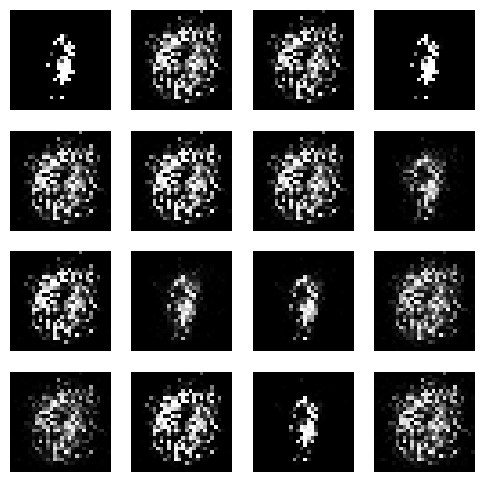

Epoch 3/20 | Loss D: 1.0686 | Loss G: 1.7277
Epoch 4/20 | Loss D: 1.0782 | Loss G: 1.8057


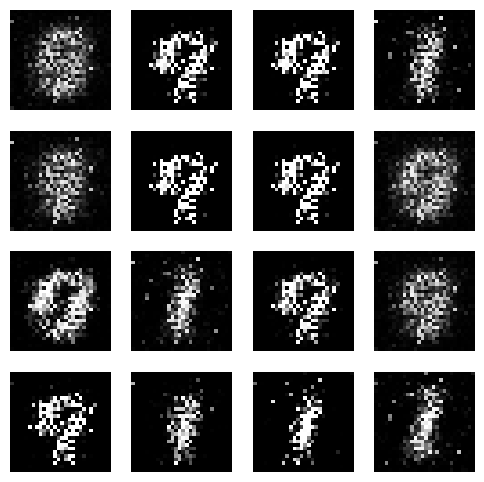

Epoch 5/20 | Loss D: 1.1099 | Loss G: 1.8168
Epoch 6/20 | Loss D: 0.9562 | Loss G: 2.0699


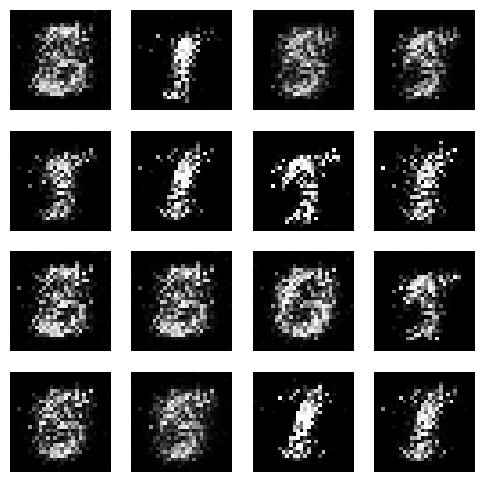

Epoch 7/20 | Loss D: 0.9985 | Loss G: 2.0653
Epoch 8/20 | Loss D: 0.8716 | Loss G: 1.9330


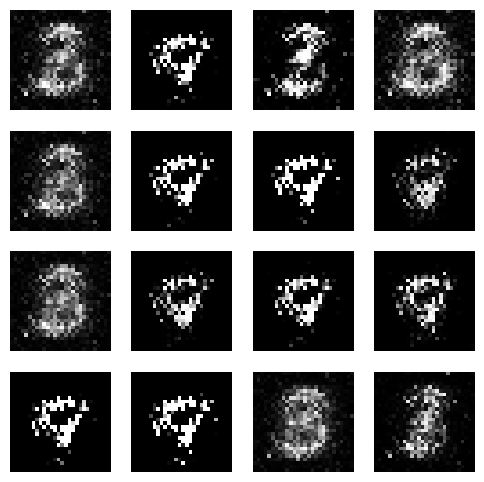

Epoch 9/20 | Loss D: 1.0695 | Loss G: 1.9225
Epoch 10/20 | Loss D: 0.8815 | Loss G: 1.9311


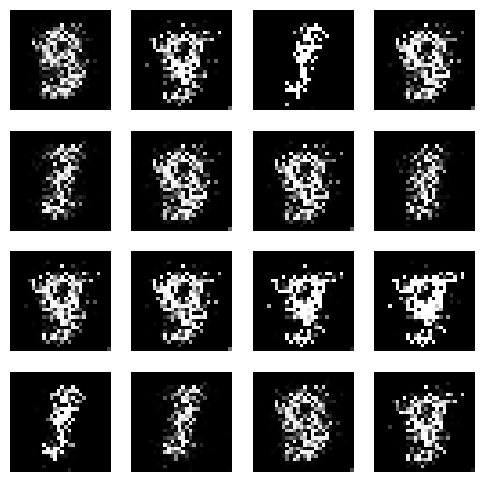

Epoch 11/20 | Loss D: 0.9545 | Loss G: 1.9361
Epoch 12/20 | Loss D: 0.9223 | Loss G: 1.8608


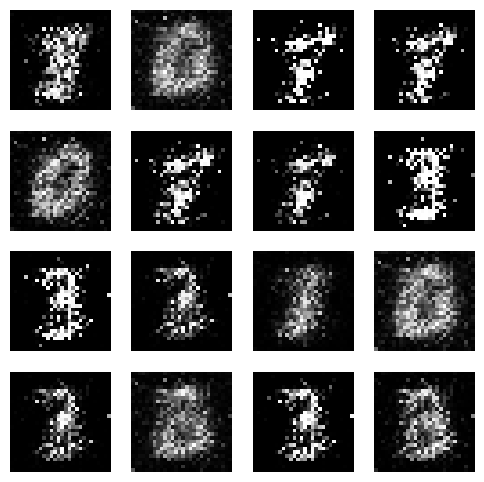

Epoch 13/20 | Loss D: 0.8959 | Loss G: 1.9492
Epoch 14/20 | Loss D: 0.9338 | Loss G: 2.0435


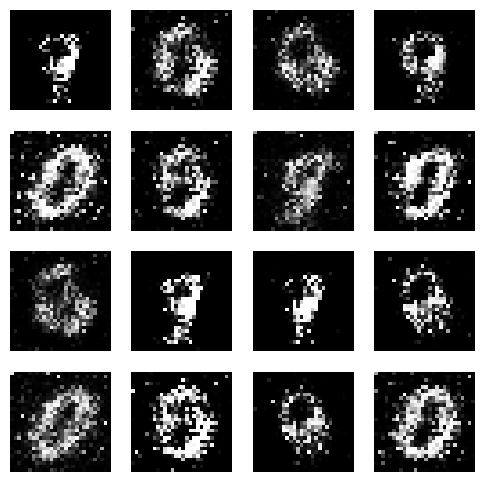

Epoch 15/20 | Loss D: 1.0044 | Loss G: 1.7912
Epoch 16/20 | Loss D: 1.0190 | Loss G: 2.1804


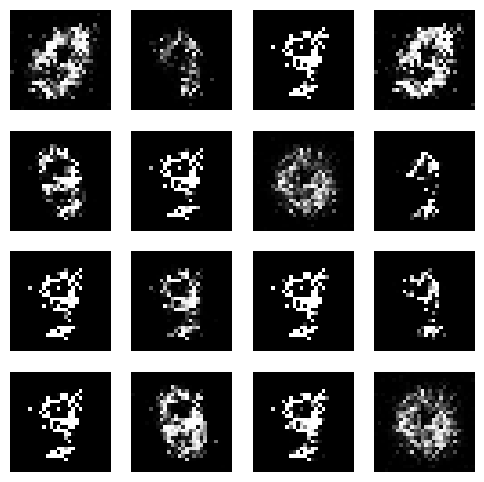

Epoch 17/20 | Loss D: 0.9574 | Loss G: 2.3141
Epoch 18/20 | Loss D: 0.8865 | Loss G: 1.9512


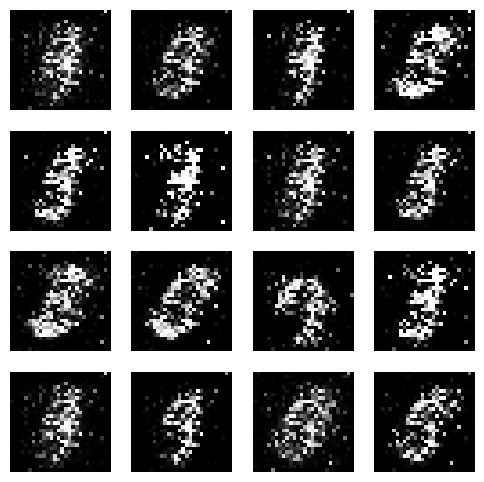

Epoch 19/20 | Loss D: 0.9122 | Loss G: 2.2650
Epoch 20/20 | Loss D: 0.9069 | Loss G: 1.9351


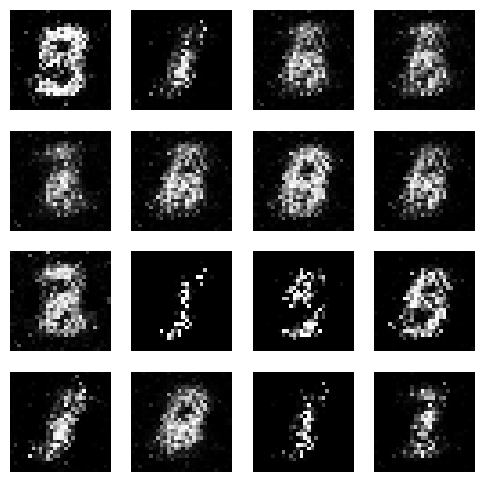

In [32]:
num_epochs = 20

for epoch in range(num_epochs):
    avg_loss_G, avg_loss_D = train_one_epoch(
        G, D, dataloader, optimizer_G, optimizer_D, criterion, latent_dim, device
    )

    print(f"Epoch {epoch+1}/{num_epochs} | Loss D: {avg_loss_D:.4f} | Loss G: {avg_loss_G:.4f}")

    if (epoch + 1) % 2 == 0:
        show_generated_images(G)

## Problem 3: Clustering


### Overview and Roadmap

This section is the most scaffold-heavy because there are several numbered subparts, several plots, and two different algorithms. The goal is for the markdown to tell you exactly which code cells correspond to which written question.

#### What this problem asks you to do

1. Implement K-means and verify its objective decreases over iterations.
2. Visualize cluster means across multiple random restarts.
3. Repeat after standardizing pixels and compare the centroids.
4. Implement HAC with max, min, and centroid linkage on the smaller dataset.
5. Compare cluster sizes and confusion matrices across methods.
6. Use those plots to support the qualitative discussion questions in the writeup.

#### Data note

The original scaffold expects `data/large_dataset.npy`, `data/small_dataset.npy`, and `data/small_dataset_labels.npy`. The cell below checks for those files and recreates them from the local raw MNIST files if needed so the instructions and the code stay consistent.


This section contains the K-means and HAC implementation and the plotting code used for the clustering problem.


### Setup: Dataset Preparation


In [34]:
from pathlib import Path

def ensure_clustering_datasets(data_dir="data"):
    data_dir = Path(data_dir)
    large_path = data_dir / "large_dataset.npy"
    small_path = data_dir / "small_dataset.npy"
    small_labels_path = data_dir / "small_dataset_labels.npy"

    if large_path.exists() and small_path.exists() and small_labels_path.exists():
        return

    raw_dir = data_dir / "MNIST" / "raw"
    image_file = raw_dir / "train-images-idx3-ubyte"
    label_file = raw_dir / "train-labels-idx1-ubyte"

    with open(image_file, "rb") as f:
        image_bytes = f.read()
    images = np.frombuffer(image_bytes, dtype=np.uint8, offset=16).reshape(-1, 28 * 28).astype(np.float32)

    with open(label_file, "rb") as f:
        label_bytes = f.read()
    labels = np.frombuffer(label_bytes, dtype=np.uint8, offset=8).astype(np.int64)

    np.save(large_path, images[:5000])
    np.save(small_path, images[:300])
    np.save(small_labels_path, labels[:300])

ensure_clustering_datasets()


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from seaborn import heatmap
from scipy.spatial import distance

### Setup: Load Clustering Datasets


In [36]:
# Loading datasets

small_dataset = np.load("data/small_dataset.npy")
small_labels = np.load("data/small_dataset_labels.npy").astype(int)
large_dataset = np.load("data/large_dataset.npy")

### Section 3.1: K-Means


#### K-Means implementation

The `KMeans` class below corresponds to the first three clustering subproblems. Its helper methods match the standard alternating procedure: initialize means, compute distances, update assignments, and then recompute means. The later plotting cells call methods from this class directly, so this is the core implementation to understand first.


In [37]:
class KMeans(object):
    def __init__(self, K):
        self.K = K

    def _compute_distances(self, X):
        # (N, 1, D) - (1, K, D) -> (N, K)
        return np.sqrt(((X[:, np.newaxis, :] - self.means[np.newaxis, :, :]) ** 2).sum(axis=2))

    def _assign_clusters(self, X):
        dists = self._compute_distances(X)
        self.assignments = np.argmin(dists, axis=1)
        return dists

    def _update_means(self, X):
        for k in range(self.K):
            members = X[self.assignments == k]
            if len(members) > 0:
                self.means[k] = members.mean(axis=0)

    def _compute_objective(self, X):
        dists = self._compute_distances(X)
        return np.sum(dists[np.arange(len(X)), self.assignments] ** 2)

    def fit(self, X):
        N, D = X.shape
        indices = np.random.choice(N, self.K, replace=False)
        self.means = X[indices].copy()
        self.objective_history = []

        for _ in range(10):
            self._assign_clusters(X)
            self._update_means(X)
            self.objective_history.append(self._compute_objective(X))

    def plot_verify_objective(self):
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, len(self.objective_history) + 1), self.objective_history, marker='o')
        plt.xlabel('Iteration')
        plt.ylabel('K-means Objective')
        plt.title('K-means Objective vs Iteration')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        for i in range(1, len(self.objective_history)):
            assert self.objective_history[i] <= self.objective_history[i - 1] + 1e-8, \
                f"Objective increased at iteration {i+1}"
        print("Verified: objective never increases.")

    def get_mean_images(self):
        return self.means.copy()

    def get_cluster_sizes(self):
        return [np.sum(self.assignments == k) for k in range(self.K)]



#### Subpart 3.1.a: Verify the K-means Objective


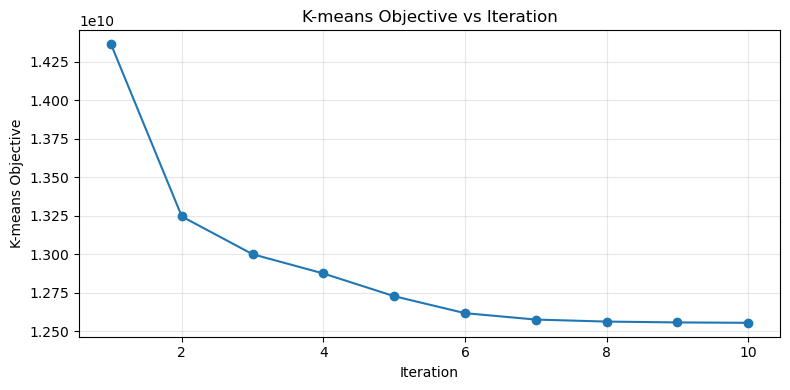

Verified: objective never increases.


In [39]:
np.random.seed(181)
KMeansClassifier = KMeans(K=10)
KMeansClassifier.fit(large_dataset)
KMeansClassifier.plot_verify_objective()

#### Helper for Subparts 3.1.b and 3.1.c


In [40]:
def make_mean_image_plot(data, standardized = False, filename=None):
    niters = 3
    K = 10
    allmeans = np.zeros((K, niters, 784))
    for i in range(niters):
        KMeansClassifier = KMeans(K=K)
        KMeansClassifier.fit(data)
        allmeans[:,i] = KMeansClassifier.get_mean_images()
    fig = plt.figure(figsize=(10,10))
    plt.suptitle('Class mean images across random restarts' + (' (standardized data)' if standardized else ''), fontsize=16)
    for k in range(K):
        for i in range(niters):
            ax = fig.add_subplot(K, niters, 1+niters*k+i)
            plt.setp(ax.get_xticklabels(), visible=False)
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.tick_params(axis='both', which='both', length=0)
            if k == 0: plt.title('Iter '+str(i))
            if i == 0: ax.set_ylabel('Class '+str(k), rotation=90)
            plt.imshow(allmeans[k,i].reshape(28,28), cmap='Greys_r')
    if filename:
        plt.savefig(f'img_output/{filename}') 
    plt.show()

#### Subpart 3.1.b: Mean Images from Raw Pixels


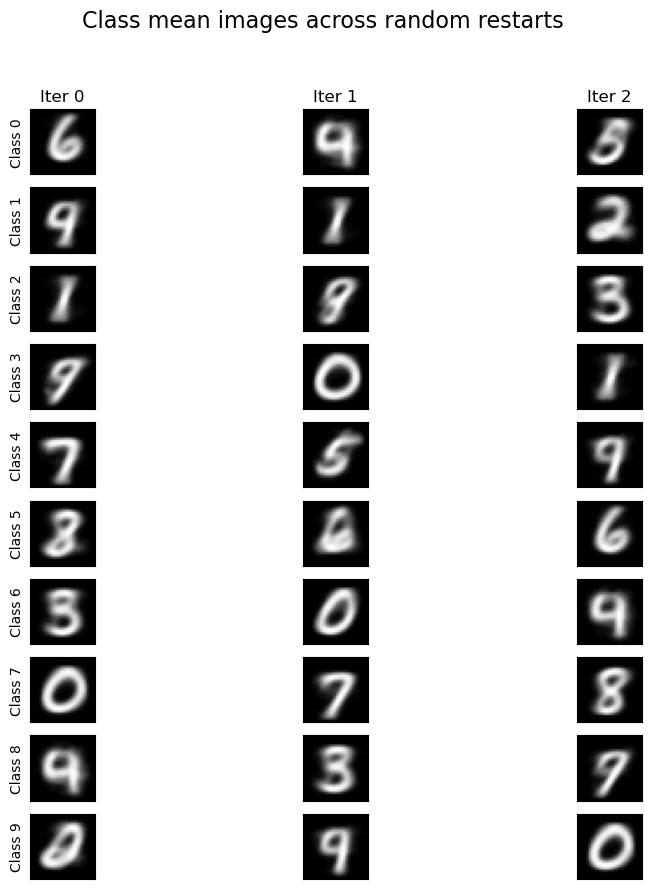

In [43]:
make_mean_image_plot(large_dataset, filename='p2.2.png')

#### Subpart 3.1.c: Mean Images after Standardization


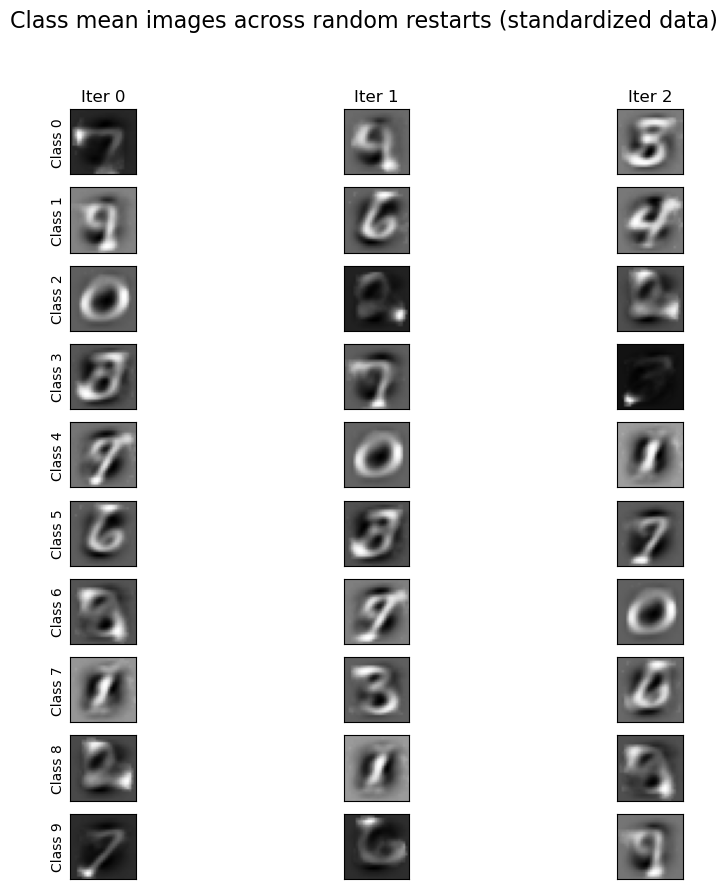

In [44]:
pixel_mean = large_dataset.mean(axis=0)
pixel_std = large_dataset.std(axis=0)
pixel_std[pixel_std == 0] = 1.0
large_dataset_std = (large_dataset - pixel_mean) / pixel_std

make_mean_image_plot(large_dataset_std, standardized = True, filename='p2.3.png')


### Section 3.2: Hierarchical Agglomerative Clustering


For HAC, the main scaffold difference is that merges happen between clusters rather than between points and centroids. The implementation below tracks the cluster assignments over time so later cells can recover the partition when there are exactly 10 clusters.


In [45]:
class HAC(object):
    def __init__(self, linkage):
        self.linkage = linkage

    def fit(self, X):
        self.X = X.copy()
        N = X.shape[0]

        # Each point starts in its own cluster
        clusters = {i: [i] for i in range(N)}
        centroids = {i: X[i].copy() for i in range(N)}

        dist_matrix = distance.cdist(X, X, metric='euclidean')
        np.fill_diagonal(dist_matrix, np.inf)

        self.merge_history = []
        active = set(range(N))

        for step in range(N - 1):
            # Find the pair of active clusters with minimum distance
            min_dist = np.inf
            merge_i, merge_j = -1, -1
            active_list = sorted(active)
            for idx_a in range(len(active_list)):
                for idx_b in range(idx_a + 1, len(active_list)):
                    i, j = active_list[idx_a], active_list[idx_b]
                    if dist_matrix[i, j] < min_dist:
                        min_dist = dist_matrix[i, j]
                        merge_i, merge_j = i, j

            new_cluster = clusters[merge_i] + clusters[merge_j]
            clusters[merge_i] = new_cluster
            del clusters[merge_j]
            active.remove(merge_j)

            if self.linkage == 'centroid':
                centroids[merge_i] = X[new_cluster].mean(axis=0)

            for k in active:
                if k == merge_i:
                    continue
                if self.linkage == 'max':
                    new_dist = max(dist_matrix[merge_i, k], dist_matrix[merge_j, k])
                elif self.linkage == 'min':
                    new_dist = min(dist_matrix[merge_i, k], dist_matrix[merge_j, k])
                elif self.linkage == 'centroid':
                    new_dist = np.linalg.norm(centroids[merge_i] - centroids[k])
                dist_matrix[merge_i, k] = new_dist
                dist_matrix[k, merge_i] = new_dist

            dist_matrix[merge_j, :] = np.inf
            dist_matrix[:, merge_j] = np.inf

            self.merge_history.append((merge_i, merge_j))

            if len(active) <= 1:
                break

        self.clusters_at_end = clusters

    def get_k_clusters(self, k):
        N = self.X.shape[0]
        clusters = {i: [i] for i in range(N)}
        active = set(range(N))

        merges_needed = N - k
        for step in range(merges_needed):
            merge_i, merge_j = self.merge_history[step]
            clusters[merge_i] = clusters[merge_i] + clusters[merge_j]
            del clusters[merge_j]
            active.remove(merge_j)

        assignments = np.zeros(N, dtype=int)
        for label, (cid, members) in enumerate(clusters.items()):
            for m in members:
                assignments[m] = label
        return assignments

    def get_mean_images(self, n_clusters):
        assignments = self.get_k_clusters(n_clusters)
        means = []
        for k in range(n_clusters):
            members = self.X[assignments == k]
            means.append(members.mean(axis=0))
        return np.array(means)

    def get_cluster_sizes(self, n_clusters):
        assignments = self.get_k_clusters(n_clusters)
        return [np.sum(assignments == k) for k in range(n_clusters)]



#### Subpart 3.2.a: HAC Mean Images


Done: max
Done: min
Done: centroid


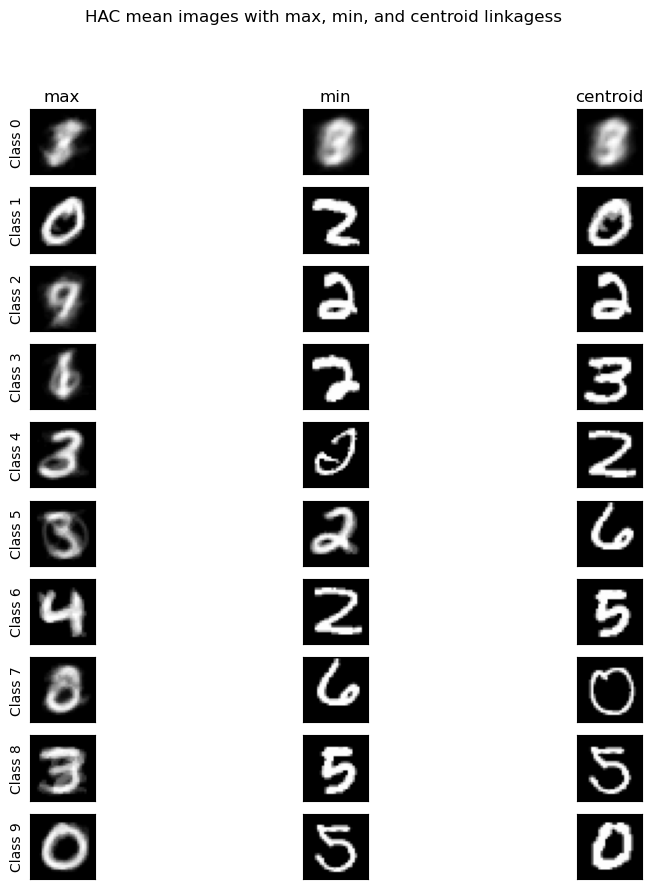

In [46]:
LINKAGES = [ 'max', 'min', 'centroid' ]
n_clusters = 10
cluster_sizes = []

fig = plt.figure(figsize=(10,10))
plt.suptitle("HAC mean images with max, min, and centroid linkagess")
for l_idx, l in enumerate(LINKAGES):
    # Fit HAC
    hac = HAC(l)
    hac.fit(small_dataset)
    mean_images = hac.get_mean_images(n_clusters)
    cluster_sizes.append(hac.get_cluster_sizes(n_clusters)) # used in Part 8, append here to avoid re-fitting
    # Make plot
    for m_idx in range(mean_images.shape[0]):
        m = mean_images[m_idx]
        ax = fig.add_subplot(n_clusters, len(LINKAGES), l_idx + m_idx*len(LINKAGES) + 1)
        plt.setp(ax.get_xticklabels(), visible=False)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(axis='both', which='both', length=0)
        if m_idx == 0: plt.title(l)
        if l_idx == 0: ax.set_ylabel('Class '+str(m_idx), rotation=90)
        plt.imshow(m.reshape(28,28), cmap='Greys_r')
    print("Done:", l)
plt.savefig('img_output/p2.4.png') 
plt.show()

#### Subpart 3.2.b: Cluster-Size Plots


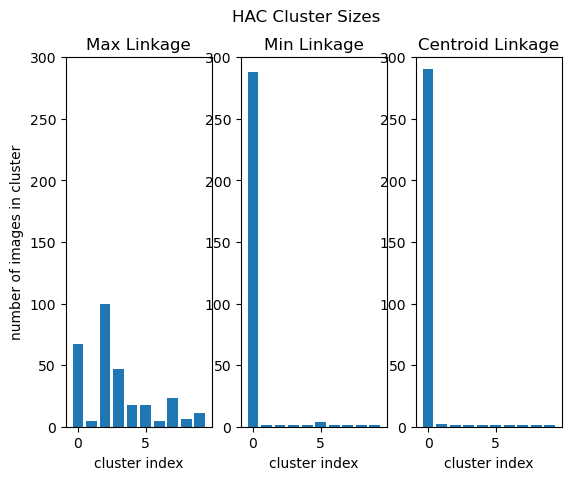

In [47]:
# HAC graphs
def plot_cluster_sizes(n_clusters, cluster_sizes, filename=None):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    fig.suptitle("HAC Cluster Sizes")
    ax1.set_ylabel('number of images in cluster')
    cluster_idxs = [i for i in range(n_clusters)]

    def plot_sizes_per_linkage(ax, sizes, linkage):
        ax.bar(cluster_idxs, sizes)
        ax.set_title(f'{linkage} Linkage')
        ax.set_xlabel('cluster index')
        ax.set_ylim(0, 300)

    plot_sizes_per_linkage(ax1, cluster_sizes[0], 'Max')
    plot_sizes_per_linkage(ax2, cluster_sizes[1], 'Min')
    plot_sizes_per_linkage(ax3, cluster_sizes[2], 'Centroid')
    if filename:
        plt.savefig(f'img_output/{filename}') 
    plt.show()
plot_cluster_sizes(n_clusters, cluster_sizes, filename='p2.5a.png')

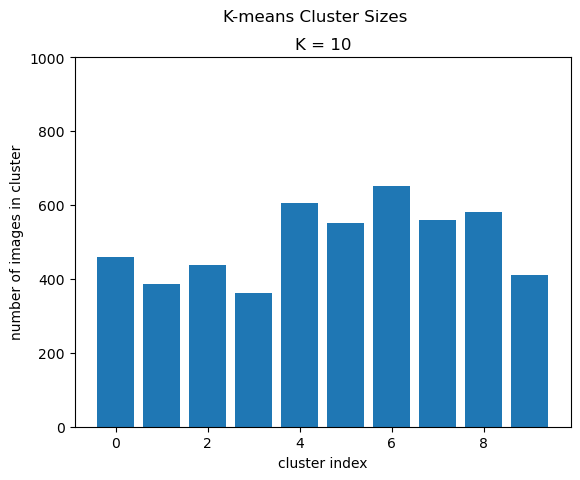

In [48]:
# K-means graphs
def plot_cluster_sizes(n_clusters, cluster_sizes, filename=None):
    fig, (ax) = plt.subplots(1, 1)
    fig.suptitle("K-means Cluster Sizes")
    ax.set_ylabel('number of images in cluster')
    cluster_idxs = [i for i in range(n_clusters)]

    def plot_sizes_per_linkage(ax, sizes, k):
        ax.bar(cluster_idxs, sizes)
        ax.set_title(f'K = {k}')
        ax.set_xlabel('cluster index')
        ax.set_ylim(0, 1000)

    plot_sizes_per_linkage(ax, cluster_sizes, str(n_clusters))
    if filename:
        plt.savefig(f'img_output/{filename}') 
    plt.show()

plot_cluster_sizes(KMeansClassifier.K, KMeansClassifier.get_cluster_sizes(), filename='p2.5b.png')

#### Subpart 3.2.c: Confusion Matrices


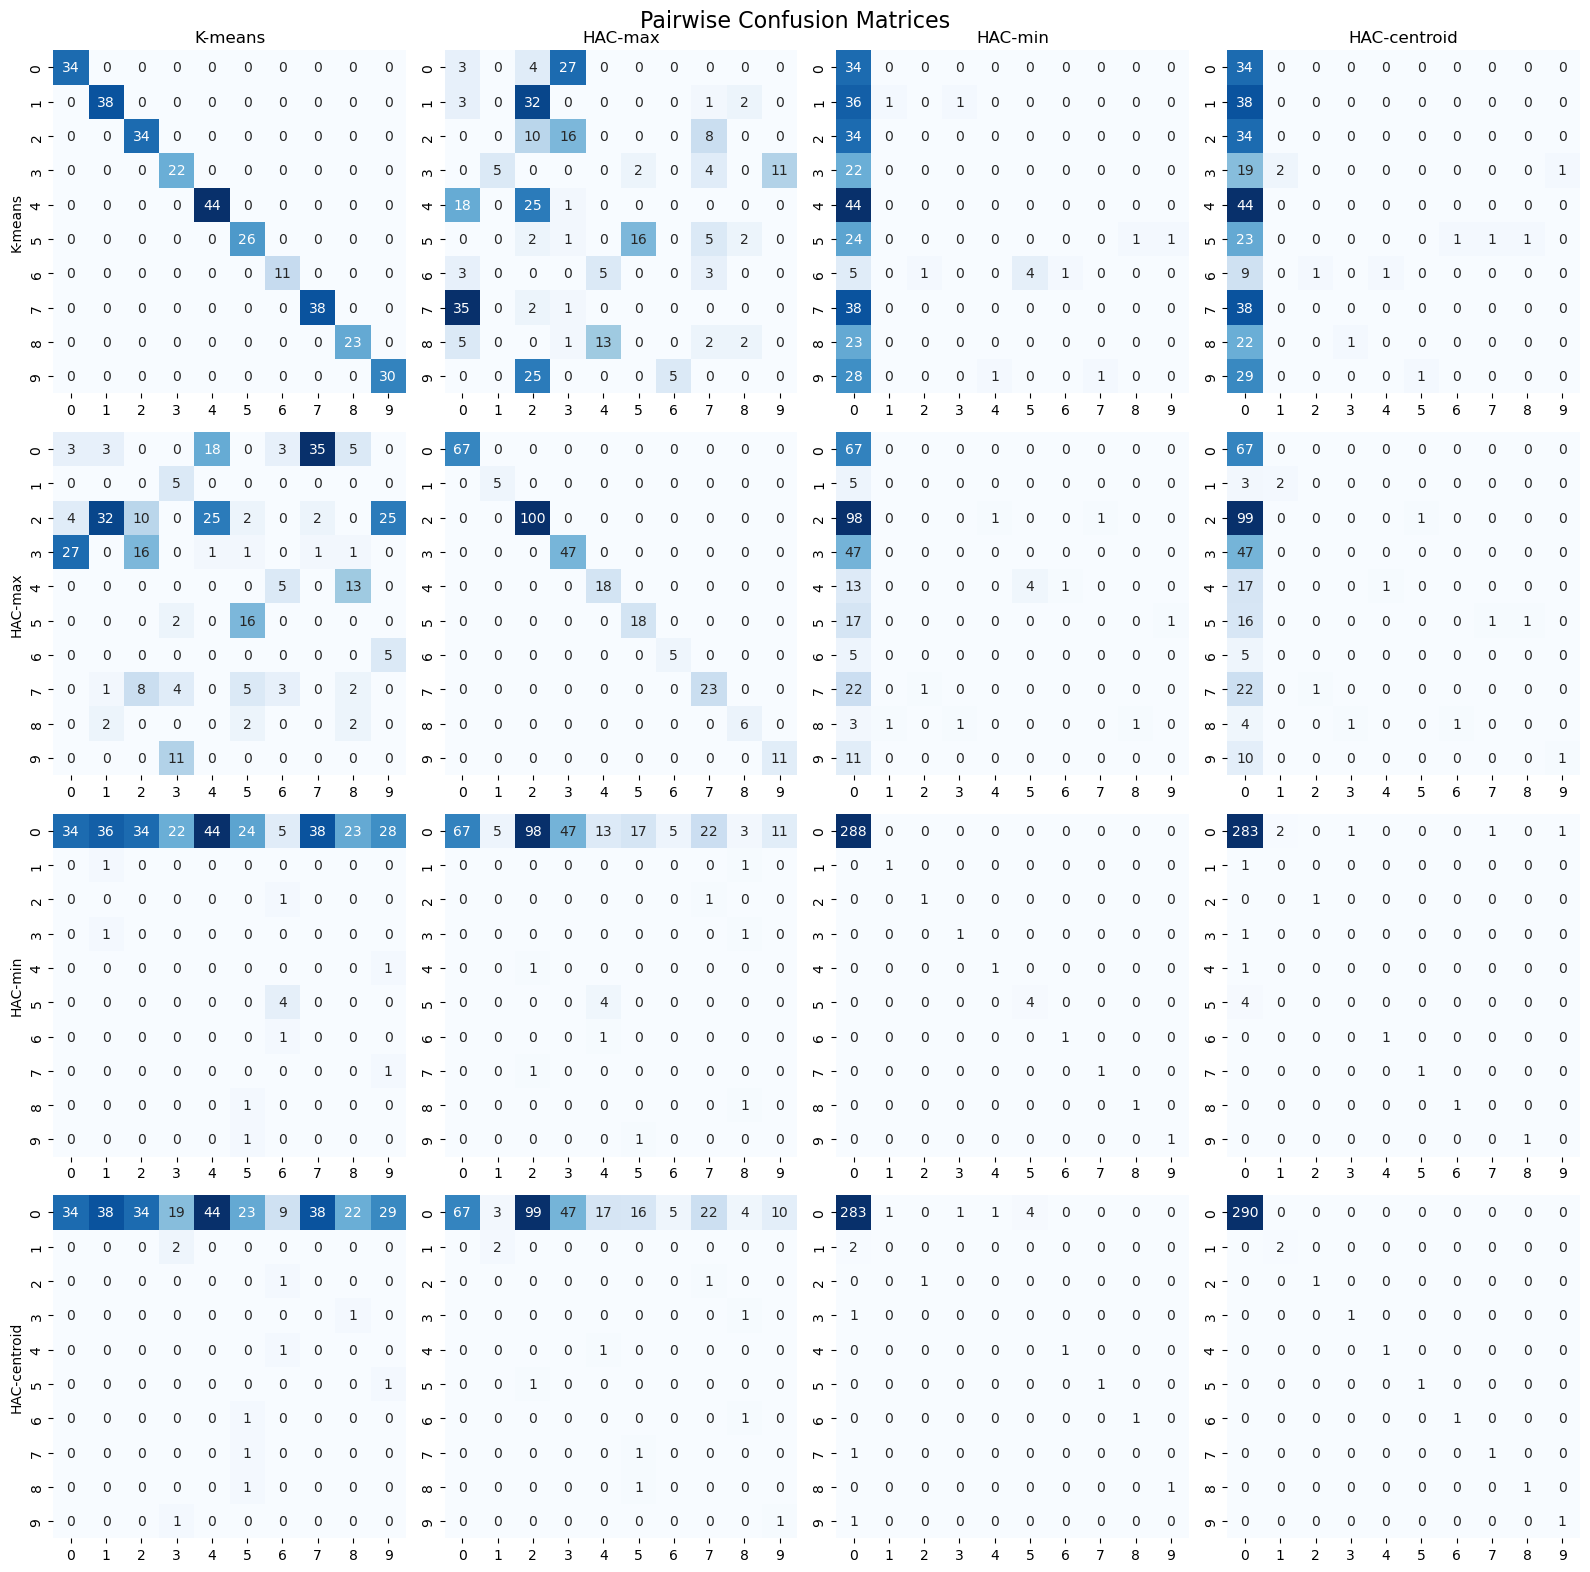

In [49]:
np.random.seed(181)
km_small = KMeans(K=10)
km_small.fit(small_dataset)
km_assignments = np.array(km_small.assignments)

hac_assignments = {}
for linkage_name in LINKAGES:
    hac_temp = HAC(linkage_name)
    hac_temp.fit(small_dataset)
    hac_assignments[linkage_name] = hac_temp.get_k_clusters(10)

methods = {'K-means': km_assignments}
for l in LINKAGES:
    methods[f'HAC-{l}'] = hac_assignments[l]

method_names = list(methods.keys())

fig, axes = plt.subplots(len(method_names), len(method_names), figsize=(16, 16))
fig.suptitle('Pairwise Confusion Matrices', fontsize=16)

for i, name_i in enumerate(method_names):
    for j, name_j in enumerate(method_names):
        labels_i = methods[name_i]
        labels_j = methods[name_j]
        K_i = max(labels_i) + 1
        K_j = max(labels_j) + 1
        conf = np.zeros((K_i, K_j), dtype=int)
        for n in range(len(labels_i)):
            conf[labels_i[n], labels_j[n]] += 1
        ax = axes[i][j]
        heatmap(conf, ax=ax, cmap='Blues', annot=True, fmt='d', cbar=False)
        if i == 0:
            ax.set_title(name_j)
        if j == 0:
            ax.set_ylabel(name_i)

plt.tight_layout()
plt.savefig('img_output/p2_confusion.png')
plt.show()


## Problem 4: PCA


### Overview and Roadmap

This section implements PCA from scratch on MNIST and keeps the same scaffold-first style as the earlier problems. The goal is to make it easy to connect each code block to the written PCA prompt in the PDF.

#### What this problem asks you to do

1. Compute PCA on the first 6000 MNIST training images.
2. Plot the top eigenvalues and the cumulative fraction of variance explained.
3. Visualize the mean image and the first 10 principal components.
4. Compare reconstruction error from the mean image and from the top 10 principal components.
5. Use those outputs to discuss the structure captured by PCA.

#### Reading guide

- The setup cells load the dataset and flatten the images.
- The next cells implement PCA and the helper statistics step by step.
- The final cells generate the plots and reconstruction-error numbers used in the writeup.


### Setup: Load the MNIST Data for PCA


In [51]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

mnist_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True)  # download MNIST
N = 6000 

x = mnist_trainset.data[:N]  # select N datapoints
x = x.flatten(1)             # flatten the images
x = x.float()                # convert pixels from uint8 to float
# x = x.numpy()              # uncomment to use numpy (optional)

### Section 4.1: Compute PCA


#### Subpart 4.1.a: PCA via SVD


In [52]:
def pca(x, n_comps=500):
    if isinstance(x, torch.Tensor):
        x_np = x.numpy()
    else:
        x_np = x

    x_mean = x_np.mean(axis=0)
    x_centered = x_np - x_mean

    U, S, Vt = np.linalg.svd(x_centered, full_matrices=False)

    eigvals = (S ** 2) / (len(x_np) - 1)
    pcomps = Vt[:n_comps]

    return x_mean, eigvals[:n_comps], pcomps



#### Subpart 4.1.b: Cumulative Fraction of Variance Explained


In [53]:
def calc_cfvs(eigvals):
    total = eigvals.sum()
    return np.cumsum(eigvals) / total



#### Subpart 4.1.c: Reconstruction Errors


In [54]:
def calc_errs(x, pcomps):
    if isinstance(x, torch.Tensor):
        x_np = x.numpy()
    else:
        x_np = x

    x_mean = x_np.mean(axis=0)
    x_centered = x_np - x_mean

    # Mean-only reconstruction: every image reconstructed as the mean
    err_mean = np.mean(np.sum((x_centered) ** 2, axis=1))

    # Top-10 PCA reconstruction
    top10 = pcomps[:10]  # (10, D)
    projections = x_centered @ top10.T  # (N, 10)
    reconstructed = projections @ top10  # (N, D)
    err_pcomp = np.mean(np.sum((x_centered - reconstructed) ** 2, axis=1))

    return err_mean, err_pcomp



### Section 4.2: Plotting and Discussion Outputs


#### Helper: Plot the Mean Image, Principal Components, and Variance Curves


In [55]:
def plot_pic(pic, ax, title=''):
    ax.imshow(pic.reshape(28, 28), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

def make_plots(eigvals, cfvs, x_mean, pcomps):
    # Eigenvalues
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(1, len(eigvals) + 1), eigvals, marker='.')
    ax1.set_xlabel('Component')
    ax1.set_ylabel('Eigenvalue')
    ax1.set_title('Leading Eigenvalues')
    ax1.grid(True, alpha=0.3)

    ax2.plot(range(1, len(cfvs) + 1), cfvs, marker='.')
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Cumulative Fraction of Variance')
    ax2.set_title('Cumulative Variance Explained')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('img_output/pca_eigenvalues.png')
    plt.show()

    # Mean image
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    plot_pic(x_mean, ax, title='Mean Image')
    plt.tight_layout()
    plt.savefig('img_output/pca_mean.png')
    plt.show()

    # First 10 principal components
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        plot_pic(pcomps[i], ax, title=f'PC {i+1}')
    plt.suptitle('First 10 Principal Components', fontsize=14)
    plt.tight_layout()
    plt.savefig('img_output/pca_components.png')
    plt.show()



#### Final PCA Run and Saved Figures


Mean-only reconstruction MSE: 3436023.50
Top-10 PCA reconstruction MSE: 1731315.38
Reduction factor: 1.98x


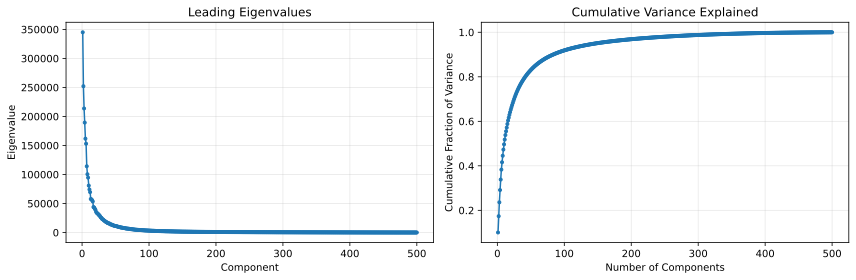

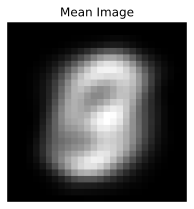

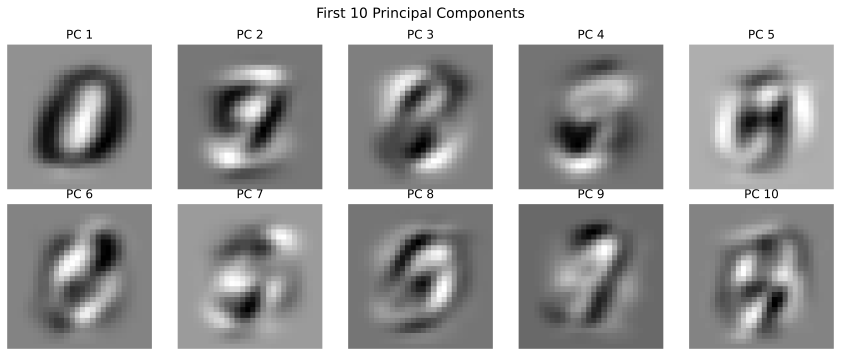

In [ ]:
import os
os.makedirs('img_output', exist_ok=True)

x_mean, eigvals, pcomps = pca(x, n_comps=500)
cfvs = calc_cfvs(eigvals)
err_mean, err_pcomp = calc_errs(x, pcomps)

print(f"Mean-only reconstruction MSE: {err_mean:.2f}")
print(f"Top-10 PCA reconstruction MSE: {err_pcomp:.2f}")
print(f"Reduction factor: {err_mean / err_pcomp:.2f}x")

make_plots(eigvals, cfvs, x_mean, pcomps)

